# Codigo: Ejemplos Modelos de Markov Ocultos

In [33]:
%%capture
#!pip install hmmlearn
# !pip install tokenizers
# !wget -O ../../assets/consti.txt https://raw.githubusercontent.com/avdata99/Constitucion-Nacional-Argentina/refs/heads/master/1853.txt

In [34]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import numpy as np
from hmmlearn.hmm import CategoricalHMM, MultinomialHMM
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

In [35]:
txt = Path("../../assets/consti.txt").read_text(encoding="utf-8").replace("\n", " ").replace("\ufeff", "")
txt[:55]

'CONSTITUCIÓN DE LA NACIÓN ARGENTINA   1 de mayo de 1853'

In [36]:
## Train hmm of txt

# letter to LabelEncoder
words = txt.split()
symbols = list(set(words))

le = LabelEncoder()
le.fit(symbols)
observations = le.transform(np.array(words))

In [37]:
hmm = CategoricalHMM(n_components=20, n_iter=1000, tol=0.01)
hmm.fit(observations.reshape(-1, 1))

Fitting a model with 43759 free scalar parameters with only 7323 data points will result in a degenerate solution.


CategoricalHMM(n_components=20, n_features=np.int64(2169), n_iter=1000,
               random_state=RandomState(MT19937) at 0x7A4D8C152A40)

In [38]:
sampled_words, states = hmm.sample(10,currstate=0)  # sample 10 words
print("Sampled words:", le.inverse_transform(sampled_words.reshape(-1)))

Sampled words: ['o' 'respecto' 'con' 'capitales' 'de' 'todos' 'los' 'ramos' 'de'
 'servicios']


In [39]:
# Initialize a BPE tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

# Pre-tokenize on whitespace (splits text into words before BPE)
tokenizer.pre_tokenizer = Whitespace()

# Configure the training
trainer = BpeTrainer(
    vocab_size=1000,  # Maximum vocabulary size
    min_frequency=2,  # Minimum frequency to include a token
    special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
)

# Create a dataset from our text
def batch_iterator(batch_size=1000):
    for i in range(0, len(txt), batch_size):
        yield txt[i:i+batch_size]

# Train the tokenizer
tokenizer.train_from_iterator(batch_iterator(), trainer)

# Save the trained tokenizer
tokenizer.save("bpe_tokenizer.json")

# Encode some example text
example_text = "Constitución Nacional Argentina"
encoded = tokenizer.encode(example_text)

print(f"Tokens: {encoded.tokens}")
print(f"IDs: {encoded.ids}")

# Display some vocabulary statistics
vocab = tokenizer.get_vocab()
print(f"\nVocabulary size: {len(vocab)}")
print("\nTop 20 tokens by ID:")
for token, id in sorted(vocab.items(), key=lambda x: x[1])[:20]:
    print(f"{token}: {id}")




Tokens: ['Constitución', 'Nacional', 'Argentina']
IDs: [255, 637, 523]

Vocabulary size: 1000

Top 20 tokens by ID:
[UNK]: 0
[CLS]: 1
[SEP]: 2
[PAD]: 3
[MASK]: 4
": 5
(: 6
): 7
,: 8
-: 9
.: 10
0: 11
1: 12
2: 13
3: 14
4: 15
5: 16
6: 17
7: 18
8: 19


In [40]:
ids = tokenizer.encode(txt).ids

In [41]:
hmm = CategoricalHMM(n_components=20, n_iter=1000, tol=0.01)
hmm.fit(np.array(ids).reshape(-1, 1))

Fitting a model with 20379 free scalar parameters with only 12092 data points will result in a degenerate solution.


CategoricalHMM(n_components=20, n_features=np.int64(1000), n_iter=1000,
               random_state=RandomState(MT19937) at 0x7A4D8C152A40)

In [42]:
sampled_ids, states = hmm.sample(10, currstate=1)  # sample 10 words
tokenizer.decode(sampled_ids.reshape(-1))

'5 que tar por C co rán las de provinci'

In [ ]:
states = hmm.predict(np.array(ids).reshape(-1, 1))

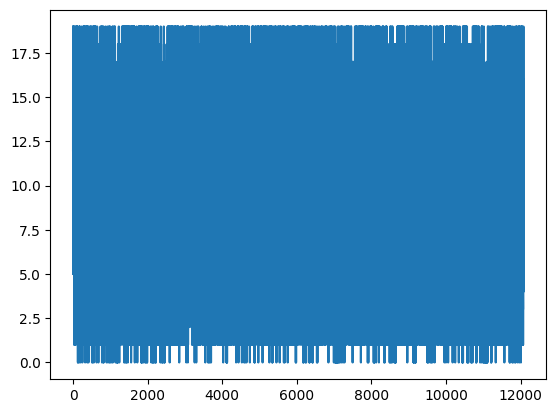